# TinyChirp SincNet-Time TensorFlow

Train a **Conv2D** model (`kernel_size=(k, 1)`) with a SincNet-style learnable frontend on raw audio (time runs along the spatial **height** dimension), export an int8 TFLite model, and write Rust quantized samples in `audio_samples/<model>.rs`.

This mirrors `building_tensorflow/cnn_time.ipynb` but replaces the first convolutional layer with a custom Sinc-like frontend whose learned filters are baked into a static `Conv2D` for inference. Rank-4 tensors throughout keep the graph compatible with microflow on device.

# TinyChirp SincNet-Time TensorFlow

Train a **Conv2D** model (`kernel_size=(k, 1)`) with a SincNet-style learnable frontend on raw audio (time runs along the spatial **height** dimension), export an int8 TFLite model, and write Rust quantized samples in `audio_samples/<model>.rs`.

This mirrors `building_tensorflow/cnn_time.ipynb` but replaces the first convolutional layer with a custom Sinc-like frontend whose learned filters are baked into a static `Conv2D` for inference. Rank-4 tensors throughout keep the graph compatible with microflow on device.

In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import tensorflow as tf

from utils import (
    TARGET_AUDIO_LEN_TIME,
    SAMPLE_RATE,
    get_paths,
    configure_tf_runtime,
    set_global_seed,
    make_time_datasets,
    build_representative_batches,
    export_keras_model_to_int8_tflite,
)

configure_tf_runtime()
set_global_seed()

MODEL_STEM = "sincnet_mimic_mel_tf"
paths = get_paths(MODEL_STEM)
OUT_TFLITE = paths.out_tflite
BATCH_SIZE = 32


In [13]:
def _time_nhwc(audio, label):
    """[B, T, 1] from utils -> [B, T, 1, 1] for Conv2D (time = height)."""
    return tf.expand_dims(audio, -1), label


train_ds, val_ds, test_ds, label_names = make_time_datasets()
train_ds = train_ds.map(_time_nhwc)
val_ds = val_ds.map(_time_nhwc)
test_ds = test_ds.map(_time_nhwc)
num_labels = len(label_names)
print("Classes:", label_names)

Found 11292 files belonging to 2 classes.
Found 1380 files belonging to 2 classes.
Found 1393 files belonging to 2 classes.
Classes: ['non_target' 'target']


## SincNet-style learnable frontend

We define a simplified SincNet-style learnable filterbank as a custom Keras layer that operates directly on the raw waveform. The layer maintains trainable parameters that are passed through a `sin` nonlinearity to produce filters, which are then applied via a 1D convolution.

In [14]:
from model_parts import SincnetConv
from utils import get_flops_native

In [ ]:
from utils import FRAME_LENGTH, FRAME_STEP

# SincNet frontend matched to the STFT used in cnn_mel: stride/kernel mimic the mel hop/window.
SINCNET_FILTERS = 32
SINCNET_STRIDE = FRAME_STEP *2                # 256 — matches mel hop. Use 512 to halve frontend MACs.
SINCNET_KERNEL_SIZE = FRAME_LENGTH - 1      # 1023 (odd)

# Multi-layer temporal CNN after the frontend (mirrors sincnet_multi).
CONV_FILTERS = 32
CONV_FILTER_SIZE = 6
CONV_STRIDE = 2
DENSE_HIDDEN = 128


def build_training_model(num_labels: int) -> tf.keras.Model:
    inputs = tf.keras.Input(shape=(TARGET_AUDIO_LEN_TIME, 1, 1))

    x = SincnetConv(
        num_filters=SINCNET_FILTERS,
        kernel_size=SINCNET_KERNEL_SIZE,
        stride=SINCNET_STRIDE,
        sample_rate=SAMPLE_RATE,
        name="sincnet_convolution",
    )(inputs)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.AveragePooling2D(pool_size=(4, 1), name="envelope_pool")(x)

    x = tf.keras.layers.Conv2D(
        filters=CONV_FILTERS,
        kernel_size=(CONV_FILTER_SIZE, 1),
        strides=(CONV_STRIDE, 1),
        padding="same",
        name="temporal_conv_1",
    )(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.AveragePooling2D(pool_size=(4, 1), name="temporal_pool_1")(x)

    x = tf.keras.layers.Conv2D(
        filters=CONV_FILTERS,
        kernel_size=(CONV_FILTER_SIZE, 1),
        strides=(CONV_STRIDE, 1),
        padding="same",
        name="temporal_conv_2",
    )(x)
    x = tf.keras.layers.ReLU()(x)

    # AveragePooling2D over the full time (height) axis — microflow-compatible substitute for GlobalAvgPool.
    x = tf.keras.layers.AveragePooling2D(
        pool_size=(x.shape[1], 1), padding="valid", name="final_pool"
    )(x)
    x = tf.keras.layers.Flatten(name="flatten")(x)

    x = tf.keras.layers.Dense(DENSE_HIDDEN, activation="relu", name="dense_hidden")(x)
    outputs = tf.keras.layers.Dense(num_labels, activation=None, name="dense_logits")(x)

    return tf.keras.Model(inputs, outputs, name="sincnet_mimic_mel_training")

training_model = build_training_model(num_labels)
training_model.summary()

flops = get_flops_native(training_model, batch_size=1)
print(f"Total FLOPs: {flops}")

Model: "sincnet_mimic_mel_training"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 47872, 1, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sincnet_convolution             │ (None, 184, 1, 32)     │            64 │
│ (SincnetConv)                   │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 184, 1, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ envelope_pool                   │ (None, 46, 1, 32)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_conv_1 (Conv2D)        │ (None, 23, 1, 32)      │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 23, 1, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_pool_1                 │ (None, 5, 1, 32)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_conv_2 (Conv2D)        │ (None, 3, 1, 32)       │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 3, 1, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ final_pool (AveragePooling2D)   │ (None, 1, 1, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_logits (Dense)            │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,898 (66.01 KB)

 Trainable params: 16,898 (66.01 KB)

 Non-trainable params: 0 (0.00 B)

Total FLOPs: 12648766


/home/nathan/Documents/tiny-chirp-microflow/building_tensorflow/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_26
Received: inputs=['Tensor(shape=(1, 47872, 1, 1))']
  warnings.warn(msg)
2026-05-07 11:51:54.429013: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-07 11:51:54.430161: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
2026-05-07 11:51:54.430259: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2026-05-07 11:51:54.430602: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successf

In [16]:
from utils import init_wandb, get_callbacks, finish_wandb

training_model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

init_wandb(MODEL_STEM, config={
    "sincnet_num_filters": SINCNET_FILTERS,
    "sincnet_kernel_size": SINCNET_KERNEL_SIZE,
    "sincnet_stride": SINCNET_STRIDE,
    "conv_filters": CONV_FILTERS,
    "conv_filter_size": CONV_FILTER_SIZE,
    "conv_stride": CONV_STRIDE,
    "dense_hidden": DENSE_HIDDEN,
})

history = training_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    validation_steps=44,
    callbacks=get_callbacks(10,5,BATCH_SIZE)
)
finish_wandb()

Epoch 1/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 25s 59ms/step - accuracy: 0.8598 - loss: 0.3078 - val_accuracy: 0.9355 - val_loss: 0.1819
Epoch 2/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step - accuracy: 0.9177 - loss: 0.2035 - val_accuracy: 0.9457 - val_loss: 0.1612
Epoch 3/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step - accuracy: 0.9286 - loss: 0.1794 - val_accuracy: 0.9384 - val_loss: 0.1471
Epoch 4/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step - accuracy: 0.9359 - loss: 0.1658 - val_accuracy: 0.9565 - val_loss: 0.1286
Epoch 5/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.9385 - loss: 0.1539 - val_accuracy: 0.9413 - val_loss: 0.1423
Epoch 6/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.9397 - loss: 0.1548 - val_accuracy: 0.9536 - val_loss: 0.1266
Epoch 7/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - accuracy: 0.9439 - loss: 0.1438 - val_accuracy: 0.9406 - val_loss: 0.1490
Epoch 8/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step - accuracy: 0.9440 - loss: 0

batch/accuracy,▁▂▅▆▆▆▆▇▆▆▇▇▇▇▇▇█▇▇█▇▇▇▇▇▇█▇▇▇██████████
batch/batch_step,▁▁▁▂▂▂▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇██
batch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
batch/loss,██▆▇▇▆▅▅▅▃▃▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁
epoch/accuracy,▁▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇████████████████████
epoch/epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇██
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▅▅▄▄▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▂▁▄▂▄▂▃▄▄▄▆▆▆▅▆▆▆▆▇▇▇▆▇▇▆▆▇▇██▇▇▇▆▇▇▇▆▇
epoch/val_loss,█▇▆▅▆▅▆▅▅▅▅▃▄▃▃▂▂▂▃▂▂▂▂▂▁▂▂▁▂▁▁▁▂▁▂▂▂▂▃▁
+6,...


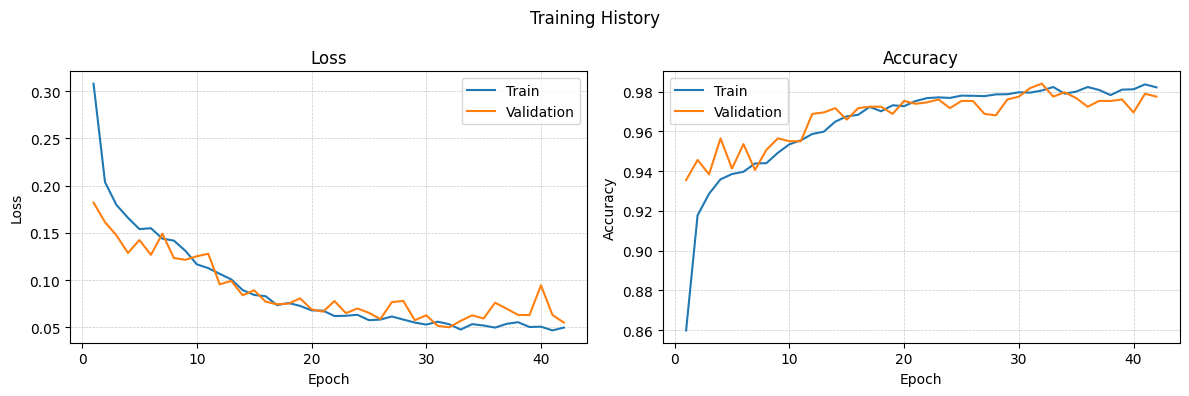

In [17]:
from utils import plot_training_history
plot_training_history(history)

## Make frontend filters into a Conv2D inference model


In [18]:
import numpy as np
frontend_layer = training_model.get_layer("sincnet_convolution")
baked_conv_layer = frontend_layer.export_to_conv2d(name="baked_sinc_conv")

infer_inputs = tf.keras.Input(shape=(TARGET_AUDIO_LEN_TIME, 1, 1))
x = baked_conv_layer(infer_inputs)
x = tf.keras.layers.ReLU()(x)
x = training_model.get_layer("envelope_pool")(x)
x = training_model.get_layer("temporal_conv_1")(x)
x = tf.keras.layers.ReLU()(x)
x = training_model.get_layer("temporal_pool_1")(x)
x = training_model.get_layer("temporal_conv_2")(x)
x = tf.keras.layers.ReLU()(x)
x = training_model.get_layer("final_pool")(x)
x = training_model.get_layer("flatten")(x)
x = training_model.get_layer("dense_hidden")(x)
outputs = training_model.get_layer("dense_logits")(x)

inference_model = tf.keras.Model(infer_inputs, outputs, name="sincnet_mimic_mel_inference")

for batch_audio, _ in test_ds.take(1):
    logits_train = training_model.predict(batch_audio.numpy(), verbose=0)
    logits_infer = inference_model.predict(batch_audio.numpy(), verbose=0)
    print(f"Max abs diff: {np.max(np.abs(logits_train - logits_infer)):.8f}")

Max abs diff: 0.00000000


2026-05-07 12:05:40.035070: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Export quantized TFLite model and Rust audio samples

We now export an int8-quantized TFLite model using the shared helpers from `building_tensorflow.utils`, and regenerate `audio_sample.rs` clips for the TinyChirp Rust runner.

In [19]:
rep_batches = build_representative_batches(test_ds, take=100)

try:
    export_keras_model_to_int8_tflite(inference_model, rep_batches, OUT_TFLITE)
    print(f"Success! Wrote {OUT_TFLITE}")
except Exception as e:
    print(f"TFLite conversion failed: {e}")

Saved artifact at '/tmp/tmprzzj5r22'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 47872, 1, 1), dtype=tf.float32, name=None)
Output Type:
  TensorSpec(shape=(1, 2), dtype=tf.float32, name=None)
Captures:
  137480364010560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137480364010032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137480364008624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137480364009328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137480364008448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137480364009504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137480364007744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137480364007920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137480364008096: TensorSpec(shape=(), dtype=tf.resource, name=None)


2026-05-07 12:05:40.361900: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Success! Wrote /home/nathan/Documents/tiny-chirp-microflow/models/sincnet_mimic_mel_tf.tflite


W0000 00:00:1778148340.600427   29595 tf_tfl_flatbuffer_helpers.cc:390] Ignored output_format.
W0000 00:00:1778148340.600441   29595 tf_tfl_flatbuffer_helpers.cc:393] Ignored drop_control_dependency.
2026-05-07 12:05:40.600578: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmprzzj5r22
2026-05-07 12:05:40.600906: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-07 12:05:40.600913: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmprzzj5r22
2026-05-07 12:05:40.605650: I tensorflow/cc/saved_model/loader.cc:234] Restoring SavedModel bundle.
2026-05-07 12:05:40.625579: I tensorflow/cc/saved_model/loader.cc:218] Running initialization op on SavedModel bundle at path: /tmp/tmprzzj5r22
2026-05-07 12:05:40.631409: I tensorflow/cc/saved_model/loader.cc:317] SavedModel load for tags { serve }; Status: success: OK. Took 30833 microseconds.
2026-05-07 12:05:40.669296: I tensorflow/comp

In [ ]:
from utils import evaluate_tflite_model

hyperparams = {
    "sincnet_filters": SINCNET_FILTERS,
    "sincnet_kernel_size": SINCNET_KERNEL_SIZE,
    "sincnet_stride": SINCNET_STRIDE,
    "frame_length": FRAME_LENGTH,
    "frame_step": FRAME_STEP,
    "conv_filters": CONV_FILTERS,
    "conv_filter_size": CONV_FILTER_SIZE,
    "conv_stride": CONV_STRIDE,
    "dense_hidden": DENSE_HIDDEN,
    "target_audio_len": TARGET_AUDIO_LEN_TIME,
    "sample_rate": SAMPLE_RATE,
    "batch_size": BATCH_SIZE,
}

train_m, test_m, avg_ms = evaluate_tflite_model(
    OUT_TFLITE, MODEL_STEM, train_ds, test_ds, hyperparams=hyperparams,
)
print(f"Avg inference: {avg_ms:.3f} ms")